# Relevance Classification — Mechanistic Approach from PDF Feature Extraction

Two parts:
- **Part A** — Rule-based scoring applied to GT (human-annotated) features — ceiling test
- **Part B** — Same rules applied to LLM-extracted features — end-to-end pipeline

In [1]:
import os
os.chdir(r"C:\Users\beav3503\dev\llm_metadata")

import sys
sys.path.insert(0, "src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from llm_metadata.schemas.fuster_features import DatasetFeaturesNormalized


## Data Loading & GT Preparation

In [2]:
# Load dev subset manifest and raw xlsx
manifest = pd.read_csv("data/manifests/dev_subset_data_paper.csv")
raw = pd.read_excel("data/dataset_092624.xlsx")

print(f"Dev subset: {len(manifest)} records")
print(f"Raw xlsx: {len(raw)} records")
print(f"Manifest columns: {list(manifest.columns[:6])}")
print(f"Raw columns sample: {list(raw.columns[:10])}")

Dev subset: 30 records
Raw xlsx: 418 records
Manifest columns: ['gt_record_id', 'source', 'title', 'abstract', 'source_doi', 'source_url']
Raw columns sample: ['id', 'url', 'title', 'full_text', 'publication_year', 'source', 'id_query', 'reason_non_valid', 'valid_yn', 'dataset_relevance']


In [3]:
# Join manifest with raw xlsx on id/record_id
df = raw[raw["id"].isin(manifest["gt_record_id"])].copy()
print(f"Matched records: {len(df)}")

# Keep both targets around:
# - human_relevance: original manual dataset_relevance label
# - gt_relevance: authors' mechanistic MC + Modulators output (paper-faithful ceiling target)
df["human_relevance"] = df["dataset_relevance"].replace({"No dataset": "X", " X": "X"}).str.strip()
df["gt_relevance"] = df["MC_relevance_modifiers"].fillna("").str.strip()

print("\nHuman dataset_relevance distribution:")
print(df["human_relevance"].value_counts())

print("\nFuster MC_relevance_modifiers distribution:")
print(df["gt_relevance"].value_counts())

# Drop cant access / rows without mechanistic labels
eval_df = df[df["gt_relevance"].isin(["H", "M", "L", "X"])].copy()
print(f"\nEvaluation records with mechanistic reference: {len(eval_df)}")
print(eval_df["gt_relevance"].value_counts())


Matched records: 30

Human dataset_relevance distribution:
human_relevance
M    12
L    11
H     6
X     1
Name: count, dtype: int64

Fuster MC_relevance_modifiers distribution:
gt_relevance
M    12
H    10
L     8
Name: count, dtype: int64

Evaluation records with mechanistic reference: 30
gt_relevance
M    12
H    10
L     8
Name: count, dtype: int64


## GT Normalization

Normalize the notebook-relevant GT fields with `DatasetFeaturesNormalized` before computing the mechanistic scores.

This gives us spreadsheet cleaning for booleans, years, numeric ranges, and list-like `data_type` values while preserving the original raw `data_type` string for the ambiguous genetic-analysis mapping.


In [4]:
normalization_fields = [
    "data_type", "temp_range_i", "temp_range_f", "spatial_range_km2",
    "multispecies", "threatened_species", "new_species_science",
    "new_species_region", "bias_north_south"
]

normalized_rows = []
for _, row in eval_df.iterrows():
    payload = {field: row.get(field) for field in normalization_fields}
    model = DatasetFeaturesNormalized.model_validate(payload)
    normalized = model.model_dump(mode="python")
    normalized["id"] = row["id"]
    normalized["raw_data_type"] = row.get("data_type")
    normalized["data_type_primary"] = normalized["data_type"][0] if normalized.get("data_type") else None
    normalized_rows.append(normalized)

normalized_df = pd.DataFrame(normalized_rows)
keep_gt_cols = [column for column in eval_df.columns if column not in normalization_fields]
eval_df = eval_df[keep_gt_cols].merge(normalized_df, on="id", how="left")

print(f"Normalized records: {len(normalized_df)}")
print("Normalization preview:")
preview_cols = [
    "id", "raw_data_type", "data_type", "data_type_primary",
    "temp_range_i", "temp_range_f", "spatial_range_km2", "multispecies"
]
eval_df[preview_cols].head(5)


Normalized records: 30
Normalization preview:


,id,raw_data_type,data_type,data_type_primary,temp_range_i,temp_range_f,spatial_range_km2,multispecies
0,5,EBV genetic analysis,[genetic_analysis],genetic_analysis,2006.0,2007.0,NaN,False
1,9,density,[density],density,2008.0,2008.0,NaN,False
2,11,presence only,[presence-only],presence-only,1999.0,2011.0,7250.0,False
3,12,other,[other],other,2004.0,2011.0,7250.0,False
4,19,"presence only, EBV genetic analysis","[presence-only, genetic_analysis]",presence-only,2011.0,2014.0,2080.0,False


## Part A — Rule-Based Scoring on GT Features

Apply the reconstructed Fuster rules to GT features and compare them to the authors' mechanistic reference (`MC_relevance_modifiers`).

`dataset_relevance` is kept separately as `human_relevance` for diagnostics, but it is not the ceiling target for this notebook.

Interpretation:
- `MC_relevance_modifiers` should be read as the output of the paper's explicit rule system: Main Classifiers followed by Modulators.
- `dataset_relevance` should be read as the spreadsheet's final manual relevance label. In practice it often agrees with `MC_relevance_modifiers`, but it is not identical to it.
- The diagnostic figure `same rules vs human dataset_relevance` therefore does **not** test whether the reconstruction is correct. It tests how much the formal Fuster rule output agrees with the separate human final label.


In [5]:
# Inspect relevant GT columns after normalization
gt_cols = [
    "id", "raw_data_type", "data_type", "data_type_primary",
    "temp_range_i", "temp_range_f", "spatial_range_km2",
    "multispecies", "threatened_species", "new_species_science", "new_species_region",
    "bias_north_south", "dataset_relevance", "human_relevance", "gt_relevance",
    "MC_dataset_type", "MC_spatial_range", "MC_temporal_range",
    "MC_relevance", "MC_relevance_modifiers"
]
available_cols = [c for c in gt_cols if c in eval_df.columns]
print("Available columns:", available_cols)
eval_df[available_cols].head(5)


Available columns: ['id', 'raw_data_type', 'data_type', 'data_type_primary', 'temp_range_i', 'temp_range_f', 'spatial_range_km2', 'multispecies', 'threatened_species', 'new_species_science', 'new_species_region', 'bias_north_south', 'dataset_relevance', 'human_relevance', 'gt_relevance', 'MC_dataset_type', 'MC_spatial_range', 'MC_temporal_range', 'MC_relevance', 'MC_relevance_modifiers']


,id,raw_data_type,data_type,data_type_primary,temp_range_i,temp_range_f,spatial_range_km2,multispecies,threatened_species,new_species_science,new_species_region,bias_north_south,dataset_relevance,human_relevance,gt_relevance,MC_dataset_type,MC_spatial_range,MC_temporal_range,MC_relevance,MC_relevance_modifiers
0,5,EBV genetic analysis,[genetic_analysis],genetic_analysis,2006.0,2007.0,NaN,False,True,False,False,False,M,M,M,H,X,L,L,M
1,9,density,[density],density,2008.0,2008.0,NaN,False,False,False,False,False,L,L,L,H,X,L,L,L
2,11,presence only,[presence-only],presence-only,1999.0,2011.0,7250.0,False,True,False,False,False,M,M,M,L,M,H,L,M
3,12,other,[other],other,2004.0,2011.0,7250.0,False,True,False,False,False,M,M,H,X,M,M,M,H
4,19,"presence only, EBV genetic analysis","[presence-only, genetic_analysis]",presence-only,2011.0,2014.0,2080.0,False,False,False,False,False,M,M,M,H,L,M,M,M


## Scoring Functions

Implement the three Main Classifiers and aggregation logic from Fuster et al.

### Ambiguities, Deviations, and Decisions

This notebook is trying to **reproduce the authors' mechanistic scoring as actually annotated**, not to reinterpret the paper from scratch. When the prose, supplement, and annotated columns disagree, we prefer the choice that reproduces `MC_relevance_modifiers` and we document that choice explicitly.

- **Target ambiguity:** `dataset_relevance` and `MC_relevance_modifiers` are not the same signal.
  Decision: Part A uses `MC_relevance_modifiers` as the ceiling target because it is the direct output of the Fuster rule system. `dataset_relevance` is retained as `human_relevance` for diagnostic comparison only.
- **Data-type ambiguity:** the GT contains free-text labels such as `genetic analysis`, while Table 2 distinguishes `EBV genetic analysis` from `non-EBV genetic analysis`.
  Decision: plain `genetic analysis` is treated as non-EBV (`L`) unless `EBV genetic` is explicit, because that is the mapping that matches the annotated classifier column.
- **Temporal-threshold ambiguity:** the paper wording says High is `>10 years`, but the annotated temporal classifier behaves like inclusive calendar-year bins `1-2=L`, `3-11=M`, `>=12=H`.
  Decision: use the inclusive binning that reproduces the annotations, and document the prose-vs-column mismatch rather than silently forcing the paper wording.
- **Modulator ambiguity:** the prose says only relevant datasets are upgraded and says that for multispecies datasets only the north-south modulator was noted, but the annotated `MC_relevance_modifiers` column empirically includes `X -> L` upgrades and multispecies-driven upgrades.
  Decision: for rule reconstruction, follow the observed annotation behavior from `MC_relevance_modifiers`; treat the prose as imperfectly aligned with the released labels.
- **Normalization ambiguity:** `DatasetFeaturesNormalized` is helpful for spreadsheet cleaning, but it normalizes both `genetic analysis` and `EBV genetic analysis` to `genetic_analysis`.
  Decision: use the normalization model for years, ranges, booleans, and list parsing, but retain the raw `data_type` string for the EBV vs non-EBV genetic distinction.
- **Metric ambiguity:** the dev subset has no `X` examples in `MC_relevance_modifiers`.
  Decision: compute macro F1 over labels actually present in the comparison so a perfect reconstruction on the dev subset reports `1.00` instead of being penalized for an absent class.

The practical rule in this notebook is: **when paper text and released annotations conflict, choose the interpretation that reproduces the released annotations, and label that choice as a documented reconstruction decision.**


In [6]:
# Score ordering for numeric comparison
SCORE_ORDER = {"H": 3, "M": 2, "L": 1, "X": 0}
SCORE_FROM_INT = {3: "H", 2: "M", 1: "L", 0: "X"}
LABEL_ORDER = ["H", "M", "L", "X"]


def present_labels(y_true, y_pred) -> list[str]:
    """Keep metrics on labels that actually appear in the comparison."""
    seen = set(pd.Series(y_true).dropna()) | set(pd.Series(y_pred).dropna())
    return [label for label in LABEL_ORDER if label in seen]


def score_data_type(raw_data_type, normalized_primary=None) -> str:
    """Score data type classifier (H/M/L/X) using raw GT plus normalized fallback.

    We preserve the raw spreadsheet string because `DatasetFeaturesNormalized`
    correctly standardizes list formatting, but it collapses both `genetic analysis`
    and `EBV genetic analysis` to `genetic_analysis`. The raw string is therefore
    still needed for the ambiguous EBV vs non-EBV distinction.
    """
    raw_text = None
    if raw_data_type is not None and not (isinstance(raw_data_type, float) and np.isnan(raw_data_type)):
        raw_text = str(raw_data_type).lower().strip()

    if raw_text not in (None, "", "nan"):
        dt = raw_text
        if dt in {"other", "unknown"}:
            return "X"
        if "non-ebv" in dt or ("genetic analysis" in dt and "ebv genetic" not in dt):
            return "L"
        if "relative abundance" in dt or "species richness" in dt or "species_richness" in dt:
            return "L"
        if any(x in dt for x in ["abundance", "density", "ebv genetic"]):
            return "H"
        if any(x in dt for x in ["distribution", "presence-absence", "presence_absence"]):
            return "M"
        if "presence" in dt:
            return "L"

    dt = None
    if normalized_primary is not None and not (isinstance(normalized_primary, float) and np.isnan(normalized_primary)):
        dt = str(normalized_primary).lower().strip()

    if dt in (None, "", "nan", "unknown", "other"):
        return "X"
    if dt == "genetic_analysis":
        return "L"
    if dt in {"abundance", "density"}:
        return "H"
    if dt in {"distribution", "presence-absence"}:
        return "M"
    if dt in {"presence-only", "species_richness"}:
        return "L"
    return "X"


def score_temporal(temp_range_i, temp_range_f) -> str:
    """Score temporal extent classifier (H/M/L/X).

    The paper prose says H is "more than 10 years", but the annotated columns line up
    with inclusive calendar-year bins of 1-2=L, 3-11=M, and >=12=H.
    This reproduces the authors' mechanistic labels on the dev subset and all but one
    apparent full-dataset outlier.
    """
    try:
        start = float(temp_range_i)
        end = float(temp_range_f)
        if np.isnan(start) or np.isnan(end):
            return "X"
        duration = end - start + 1
        if duration >= 12:
            return "H"
        elif duration >= 3:
            return "M"
        else:
            return "L"
    except (TypeError, ValueError):
        return "X"


def score_spatial(spatial_range_km2) -> str:
    """Score spatial extent classifier (H/M/L/X)."""
    try:
        km2 = float(spatial_range_km2)
        if np.isnan(km2):
            return "X"
        if km2 > 15000:
            return "H"
        elif km2 >= 5000:
            return "M"
        else:
            return "L"
    except (TypeError, ValueError):
        return "X"


def majority_vote(scores: list[str]) -> str:
    """Majority vote with Table S2 tiebreaker.

    When 2+ classifiers agree, that score wins.
    When all three differ (tiebreaker):
      - Special case: data_type=H and any X in spatio-temporal -> L
      - General rule: min(data_type, max(temporal, spatial))
    """
    from collections import Counter

    dt_score, temp_score, spatial_score = scores

    counts = Counter(scores)
    for score, count in counts.items():
        if count >= 2:
            return score

    if dt_score == "H" and (temp_score == "X" or spatial_score == "X"):
        return "L"

    best_spatiotemporal = SCORE_FROM_INT[max(SCORE_ORDER[temp_score], SCORE_ORDER[spatial_score])]
    result = SCORE_FROM_INT[min(SCORE_ORDER[dt_score], SCORE_ORDER[best_spatiotemporal])]
    return result


def apply_modulators(base_score: str, row: pd.Series) -> str:
    """Apply the empirically reconstructed modulator upgrade.

    This follows the annotated `MC_relevance_modifiers` column, even where it is a bit
    stricter or looser than the prose description in the paper:
    1. Upgrade is exactly one level regardless of how many modulators fire.
    2. Multispecies itself behaves as a modulator in the GT.
    3. X can be upgraded to L in the authors' annotations.
    """
    is_multispecies = _is_true(row.get("multispecies"))

    if is_multispecies:
        has_modulator = True
    else:
        modulator_fields = [
            "multispecies", "threatened_species", "new_species_science",
            "new_species_region", "bias_north_south"
        ]
        has_modulator = any(_is_true(row.get(f)) for f in modulator_fields)

    if not has_modulator:
        return base_score

    upgrades = {"X": "L", "L": "M", "M": "H", "H": "H"}
    return upgrades.get(base_score, base_score)


def _is_true(val) -> bool:
    """Check if a value is truthy (handles various GT formats)."""
    if val is True:
        return True
    if isinstance(val, str) and val.lower() in ("true", "1", "yes"):
        return True
    return False


def classify_relevance(row: pd.Series) -> dict:
    """Full classification pipeline for one record."""
    dt_score = score_data_type(row.get("raw_data_type"), row.get("data_type_primary"))
    temp_score = score_temporal(row.get("temp_range_i"), row.get("temp_range_f"))
    spatial_score = score_spatial(row.get("spatial_range_km2"))

    mc_score = majority_vote([dt_score, temp_score, spatial_score])
    final_score = apply_modulators(mc_score, row)

    return {
        "mc_data_type": dt_score,
        "mc_temporal": temp_score,
        "mc_spatial": spatial_score,
        "mc_relevance": mc_score,
        "pred_relevance": final_score,
    }


# Test on first row
test_row = eval_df.iloc[0]
print("Test classification:", classify_relevance(test_row))
print("Fuster reference:", test_row["gt_relevance"])
print("Human dataset_relevance:", test_row["human_relevance"])


Test classification: {'mc_data_type': 'H', 'mc_temporal': 'L', 'mc_spatial': 'X', 'mc_relevance': 'L', 'pred_relevance': 'M'}
Fuster reference: M
Human dataset_relevance: M


In [7]:
# Apply rules to GT features
results = eval_df.apply(classify_relevance, axis=1, result_type="expand")
eval_df_a = eval_df.join(results)

# Display sample
display_cols = [
    "id", "raw_data_type", "data_type_primary", "temp_range_i", "temp_range_f", "spatial_range_km2",
    "mc_data_type", "mc_temporal", "mc_spatial", "mc_relevance", "pred_relevance",
    "gt_relevance", "human_relevance"
]
available = [c for c in display_cols if c in eval_df_a.columns]
eval_df_a[available].head(10)


,id,raw_data_type,data_type_primary,temp_range_i,temp_range_f,spatial_range_km2,mc_data_type,mc_temporal,mc_spatial,mc_relevance,pred_relevance,gt_relevance,human_relevance
0,5,EBV genetic analysis,genetic_analysis,2006.0,2007.0,NaN,H,L,X,L,M,M,M
1,9,density,density,2008.0,2008.0,NaN,H,L,X,L,L,L,L
2,11,presence only,presence-only,1999.0,2011.0,7250.0,L,H,M,L,M,M,M
3,12,other,other,2004.0,2011.0,7250.0,X,M,M,M,H,H,M
4,19,"presence only, EBV genetic analysis",presence-only,2011.0,2014.0,2080.0,H,M,L,M,M,M,M
5,24,EBV genetic analysis,genetic_analysis,2008.0,2008.0,500000.0,H,L,H,H,H,H,H
6,27,"presence only, EBV genetic analysis",presence-only,2010.0,2014.0,NaN,H,M,X,L,M,M,M
7,29,abundance,abundance,1986.0,2000.0,535355.0,H,H,H,H,H,H,H
8,30,presence only,presence-only,1947.0,1985.0,630000.0,L,H,H,H,H,H,H
9,31,EBV genetic analysis,genetic_analysis,2002.0,2004.0,NaN,H,M,X,L,L,L,L


## MC Column Audit

Compare every computed mechanistic classifier column to its annotated `MC_*` counterpart from the GT.

This is the notebook's direct check that our assumptions for ambiguous fields are actually consistent with the released annotations, not just with the final relevance label.


In [8]:
mc_pairs = [
    ("MC_dataset_type", "mc_data_type"),
    ("MC_temporal_range", "mc_temporal"),
    ("MC_spatial_range", "mc_spatial"),
    ("MC_relevance", "mc_relevance"),
    ("MC_relevance_modifiers", "pred_relevance"),
]

mc_audit_rows = []
for gt_col, calc_col in mc_pairs:
    valid = eval_df_a[gt_col].isin(LABEL_ORDER)
    matches = eval_df_a.loc[valid, gt_col] == eval_df_a.loc[valid, calc_col]
    mc_audit_rows.append({
        "GT column": gt_col,
        "Computed column": calc_col,
        "Rows compared": int(valid.sum()),
        "Matches": int(matches.sum()),
        "Mismatches": int((~matches).sum()),
        "Accuracy": round(matches.mean(), 3) if len(matches) else None,
    })

mc_audit_df = pd.DataFrame(mc_audit_rows)
mc_audit_df


,GT column,Computed column,Rows compared,Matches,Mismatches,Accuracy
0,MC_dataset_type,mc_data_type,30,30,0,1.0
1,MC_temporal_range,mc_temporal,30,30,0,1.0
2,MC_spatial_range,mc_spatial,30,30,0,1.0
3,MC_relevance,mc_relevance,30,30,0,1.0
4,MC_relevance_modifiers,pred_relevance,30,30,0,1.0


In [9]:
mismatch_frames = []
for gt_col, calc_col in mc_pairs:
    valid = eval_df_a[gt_col].isin(LABEL_ORDER)
    mismatches = eval_df_a.loc[
        valid & (eval_df_a[gt_col] != eval_df_a[calc_col]),
        [
            "id", "raw_data_type", "data_type", "data_type_primary",
            "temp_range_i", "temp_range_f", "spatial_range_km2",
            "multispecies", "threatened_species", "new_species_science",
            "new_species_region", "bias_north_south",
            gt_col, calc_col, "human_relevance", "gt_relevance"
        ],
    ].copy()
    if not mismatches.empty:
        mismatches.insert(1, "GT column", gt_col)
        mismatches.insert(2, "Computed column", calc_col)
        mismatch_frames.append(mismatches)

if mismatch_frames:
    mc_mismatches_df = pd.concat(mismatch_frames, ignore_index=True)
    mc_mismatches_df
else:
    print("All computed mechanistic columns match their annotated MC_* counterparts on the dev subset.")


All computed mechanistic columns match their annotated MC_* counterparts on the dev subset.


## Part A — Metrics vs Fuster Mechanistic Reference


In [10]:
labels_a = present_labels(eval_df_a["gt_relevance"], eval_df_a["pred_relevance"])
y_true = eval_df_a["gt_relevance"]
y_pred_a = eval_df_a["pred_relevance"]

print("=== Part A: Rules on GT Features vs Fuster MC_relevance_modifiers ===\n")
print(classification_report(y_true, y_pred_a, labels=labels_a, zero_division=0))

# Binary collapse: H+M -> relevant, L+X -> not relevant
def binary_collapse(s):
    return "relevant" if s in ("H", "M") else "not_relevant"

y_true_bin = y_true.map(binary_collapse)
y_pred_a_bin = y_pred_a.map(binary_collapse)

p_a = precision_score(y_true_bin, y_pred_a_bin, pos_label="relevant", zero_division=0)
r_a = recall_score(y_true_bin, y_pred_a_bin, pos_label="relevant", zero_division=0)
f1_a = f1_score(y_true_bin, y_pred_a_bin, pos_label="relevant", zero_division=0)
macro_f1_a = f1_score(y_true, y_pred_a, labels=labels_a, average="macro", zero_division=0)

print(f"\nBinary (H+M=relevant vs L+X=not_relevant):")
print(f"  Precision: {p_a:.3f}  Recall: {r_a:.3f}  F1: {f1_a:.3f}")
print(f"\nMacro F1 over present labels {labels_a}: {macro_f1_a:.3f}")


=== Part A: Rules on GT Features vs Fuster MC_relevance_modifiers ===

              precision    recall  f1-score   support

           H       1.00      1.00      1.00        10
           M       1.00      1.00      1.00        12
           L       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Binary (H+M=relevant vs L+X=not_relevant):
  Precision: 1.000  Recall: 1.000  F1: 1.000

Macro F1 over present labels ['H', 'M', 'L']: 1.000


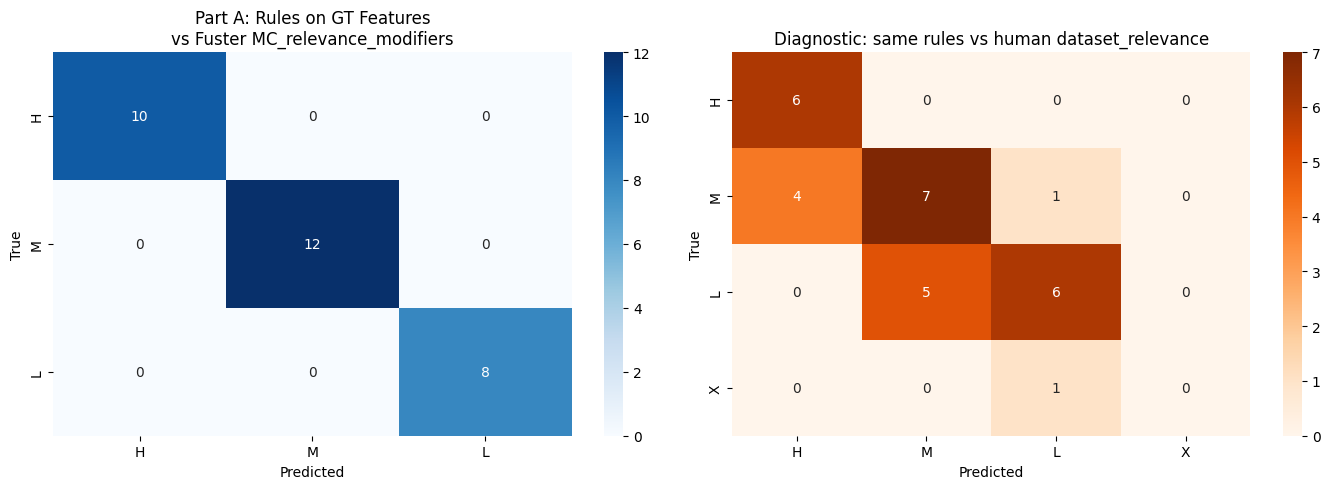

Saved confusion matrix to notebooks/results/


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_a = confusion_matrix(y_true, y_pred_a, labels=labels_a)
sns.heatmap(cm_a, annot=True, fmt="d", xticklabels=labels_a, yticklabels=labels_a,
            cmap="Blues", ax=axes[0])
axes[0].set_title("Part A: Rules on GT Features\nvs Fuster MC_relevance_modifiers")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

human_valid = eval_df_a["human_relevance"].isin(LABEL_ORDER)
human_true = eval_df_a.loc[human_valid, "human_relevance"]
human_labels = present_labels(human_true, y_pred_a.loc[human_valid])
cm_human = confusion_matrix(human_true, y_pred_a.loc[human_valid], labels=human_labels)
sns.heatmap(cm_human, annot=True, fmt="d", xticklabels=human_labels, yticklabels=human_labels,
            cmap="Oranges", ax=axes[1])
axes[1].set_title("Diagnostic: same rules vs human dataset_relevance")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("notebooks/results/relevance_mechanistic_pdf_part_a_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved confusion matrix to notebooks/results/")


In [12]:
# Diagnostic: compare the paper-faithful mechanistic target to the original human label
if "human_relevance" in eval_df_a.columns:
    human_valid = eval_df_a["human_relevance"].isin(LABEL_ORDER)
    human_true = eval_df_a.loc[human_valid, "human_relevance"]
    ref_pred = eval_df_a.loc[human_valid, "gt_relevance"]
    labels_ref = present_labels(human_true, ref_pred)

    p_ref = precision_score(human_true.map(binary_collapse), ref_pred.map(binary_collapse),
                             pos_label="relevant", zero_division=0)
    r_ref = recall_score(human_true.map(binary_collapse), ref_pred.map(binary_collapse),
                          pos_label="relevant", zero_division=0)
    f1_ref = f1_score(human_true.map(binary_collapse), ref_pred.map(binary_collapse),
                       pos_label="relevant", zero_division=0)
    macro_f1_ref = f1_score(human_true, ref_pred, labels=labels_ref, average="macro", zero_division=0)

    print("=== Diagnostic: Fuster MC_relevance_modifiers vs human dataset_relevance ===")
    print(classification_report(human_true, ref_pred, labels=labels_ref, zero_division=0))
    print(f"Binary: P={p_ref:.3f}  R={r_ref:.3f}  F1={f1_ref:.3f}")
    print(f"Macro F1 over present labels {labels_ref}: {macro_f1_ref:.3f}")
else:
    print("human_relevance column not available; skipping diagnostic comparison.")
    p_ref = r_ref = f1_ref = macro_f1_ref = None


=== Diagnostic: Fuster MC_relevance_modifiers vs human dataset_relevance ===
              precision    recall  f1-score   support

           H       0.60      1.00      0.75         6
           M       0.58      0.58      0.58        12
           L       0.75      0.55      0.63        11
           X       0.00      0.00      0.00         1

    accuracy                           0.63        30
   macro avg       0.48      0.53      0.49        30
weighted avg       0.63      0.63      0.61        30

Binary: P=0.773  R=0.944  F1=0.850
Macro F1 over present labels ['H', 'M', 'L', 'X']: 0.491


## Part B — End-to-End with LLM-Extracted Features

Run existing PDF-native extraction on dev subset, apply the same rules, and compare to GT.

In [13]:
from llm_metadata.extraction import run_manifest_extraction, ExtractionConfig
from llm_metadata.schemas.data_paper import DataPaperManifest, ExtractionMode
from llm_metadata.schemas.fuster_features import DatasetFeaturesExtraction

# Load the manifest using the proper contract
data_manifest = DataPaperManifest.load_csv("data/manifests/dev_subset_data_paper.csv")
print(f"Loaded manifest: {len(data_manifest.records)} records")

# Run extraction with DatasetFeaturesExtraction schema (same schema prompt_eval uses)
# Uses joblib cache — will reuse cached PDF-native calls when available
config = ExtractionConfig(text_format=DatasetFeaturesExtraction)
run_artifact = run_manifest_extraction(
    manifest=data_manifest,
    mode=ExtractionMode.PDF_NATIVE,
    config=config,
)

total = len(run_artifact.records)
success = sum(1 for r in run_artifact.records if r.status == "success")
errors = sum(1 for r in run_artifact.records if r.status == "error")
skipped = total - success - errors

print(f"\nExtraction complete:")
print(f"  Total records: {total}")
print(f"  Success: {success}")
print(f"  Skipped: {skipped}")
print(f"  Errors: {errors}")
print(f"  Total cost: ${run_artifact.total_cost_usd:.4f}")

2026-04-09 11:00:22 | INFO     | llm_metadata.extraction:run_manifest_extraction:362 | Starting manifest extraction mode=pdf_native records=30 parallelism=1 model=gpt-5-mini reasoning_effort=low prompt_module=prompts.pdf_file description= skip_cache=False


2026-04-09 11:00:22 | INFO     | llm_metadata.extraction:run_manifest_extraction:399 | [1/30] Extracting gt_record_id=5 record_id=10.1093/jhered/esx103 title=Data from: Paternity analysis of wood turtles (Glyptemys insculpta) reveals complex mating patterns


2026-04-09 11:00:22 | INFO     | llm_metadata.gpt_extract:extract_from_pdf_file:317 | Starting pdf_native extraction pdf_path=data\pdfs\fuster\10.1093_jhered_esx103.pdf file_id=file-D8Vrwkb7ZZtG7bnTrHbZhB model=gpt-5-mini schema=DatasetFeaturesExtraction cache=miss


Loaded manifest: 30 records


2026-04-09 11:00:22 | DEBUG    | llm_metadata.gpt_extract:_response_parse_pdf:289 | Calling OpenAI Responses API for native PDF extraction model=gpt-5-mini schema=DatasetFeaturesExtraction file_id=file-D8Vrwkb7ZZtG7bnTrHbZhB


...

2026-04-09 11:19:00 | DEBUG    | llm_metadata.gpt_extract:_response_parse_pdf:289 | Calling OpenAI Responses API for native PDF extraction model=gpt-5-mini schema=DatasetFeaturesExtraction file_id=file-Pj1bhCEoXh1kLVLSiHSRB4


2026-04-09 11:20:21 | INFO     | llm_metadata.gpt_extract:extract_from_pdf_file:345 | Completed pdf_native extraction pdf_path=data\pdfs\fuster\10.1603_0013-8746%282005%29098%5B0565%3AWCCDAA%5D2.0.CO%3B2.pdf file_id=file-Pj1bhCEoXh1kLVLSiHSRB4 cache=miss cost=$0.0165


2026-04-09 11:20:21 | INFO     | llm_metadata.extraction:run_manifest_extraction:416 | [30/30] Finished gt_record_id=351 status=success method=pdf_native cost=$0.0165


2026-04-09 11:20:21 | INFO     | llm_metadata.extraction:run_manifest_extraction:468 | Completed manifest extraction mode=pdf_native records=30 total_cost=$0.4145



Extraction complete:
  Total records: 30
  Success: 30
  Skipped: 0
  Errors: 0
  Total cost: $0.4145


In [14]:
# Build DataFrame from run records (output is a dict, not a feature object)
records_data = []
for rec in run_artifact.records:
    row = {
        "record_id": rec.record_id,
        "gt_record_id": rec.gt_record_id,
        "status": rec.status,
    }
    if rec.output:
        feat = rec.output  # dict
        dt = feat.get("data_type")
        row["data_type"] = dt
        row["data_type_primary"] = dt[0] if isinstance(dt, list) and dt else (dt if dt else None)
        row["temp_range_i"] = feat.get("temp_range_i")
        row["temp_range_f"] = feat.get("temp_range_f")
        row["spatial_range_km2"] = feat.get("spatial_range_km2")
        row["multispecies"] = feat.get("multispecies")
        row["threatened_species"] = feat.get("threatened_species")
        row["new_species_science"] = feat.get("new_species_science")
        row["new_species_region"] = feat.get("new_species_region")
        row["bias_north_south"] = feat.get("bias_north_south")
    records_data.append(row)

pred_df = pd.DataFrame(records_data)
print(f"Prediction DataFrame: {len(pred_df)} rows")
print(pred_df[["record_id", "gt_record_id", "status", "data_type_primary", "temp_range_i", "temp_range_f", "spatial_range_km2"]].head())

Prediction DataFrame: 30 rows
                      record_id  gt_record_id   status data_type_primary  \
0         10.1093/jhered/esx103             5  success  genetic_analysis   
1  10.1371/journal.pone.0128238             9  success         abundance   
2  10.1371/journal.pone.0073695            11  success       time_series   
3             10.1002/ece3.4685            12  success     presence-only   
4         10.1093/jhered/esw073            19  success  genetic_analysis   

   temp_range_i  temp_range_f  spatial_range_km2  
0        2006.0        2007.0                NaN  
1        2008.0        2008.0                NaN  
2        1999.0        2011.0             7250.0  
3        2004.0        2011.0             7250.0  
4        2011.0        2014.0             2080.0  


In [15]:
# Join with GT on gt_record_id / id
pred_with_gt = pred_df.merge(
    eval_df[["id", "gt_relevance", "human_relevance"]],
    left_on="gt_record_id",
    right_on="id",
    how="inner"
)
print(f"Records with GT match: {len(pred_with_gt)}")

# Apply rule-based scoring to LLM-extracted features
results_b = pred_with_gt.apply(classify_relevance, axis=1, result_type="expand")
pred_eval_df = pred_with_gt.join(results_b)

print("\nSample results:")
cols_b = ["record_id", "data_type", "temp_range_i", "temp_range_f", "spatial_range_km2",
          "pred_relevance", "gt_relevance", "human_relevance"]
pred_eval_df[cols_b].head(8)


Records with GT match: 30

Sample results:


,record_id,data_type,temp_range_i,temp_range_f,spatial_range_km2,pred_relevance,gt_relevance,human_relevance
0,10.1093/jhered/esx103,[genetic_analysis],2006.0,2007.0,NaN,M,M,M
1,10.1371/journal.pone.0128238,[abundance],2008.0,2008.0,NaN,M,L,L
2,10.1371/journal.pone.0073695,"[time_series, presence-only]",1999.0,2011.0,7250.0,L,M,M
3,10.1002/ece3.4685,"[presence-only, time_series]",2004.0,2011.0,7250.0,H,H,M
4,10.1093/jhered/esw073,[genetic_analysis],2011.0,2014.0,2080.0,L,M,M
5,10.1002/ece3.3906,[genetic_analysis],2008.0,2009.0,NaN,L,H,H
6,10.1111/ddi.12496,"[genetic_analysis, presence-only]",2003.0,2014.0,13993.0,M,M,M
7,10.1002/ece3.1476,[abundance],1986.0,2000.0,535355.0,H,H,H


In [16]:
labels_b = present_labels(pred_eval_df["gt_relevance"], pred_eval_df["pred_relevance"])
y_true_b = pred_eval_df["gt_relevance"]
y_pred_b = pred_eval_df["pred_relevance"]

print("=== Part B: Rules on PDF-Extracted Features vs Fuster MC_relevance_modifiers ===\n")
print(classification_report(y_true_b, y_pred_b, labels=labels_b, zero_division=0))

y_true_b_bin = y_true_b.map(binary_collapse)
y_pred_b_bin = y_pred_b.map(binary_collapse)

p_b = precision_score(y_true_b_bin, y_pred_b_bin, pos_label="relevant", zero_division=0)
r_b = recall_score(y_true_b_bin, y_pred_b_bin, pos_label="relevant", zero_division=0)
f1_b = f1_score(y_true_b_bin, y_pred_b_bin, pos_label="relevant", zero_division=0)
macro_f1_b = f1_score(y_true_b, y_pred_b, labels=labels_b, average="macro", zero_division=0)

print(f"\nBinary (H+M=relevant vs L+X=not_relevant):")
print(f"  Precision: {p_b:.3f}  Recall: {r_b:.3f}  F1: {f1_b:.3f}")
print(f"\nMacro F1 over present labels {labels_b}: {macro_f1_b:.3f}")


=== Part B: Rules on PDF-Extracted Features vs Fuster MC_relevance_modifiers ===

              precision    recall  f1-score   support

           H       0.80      0.40      0.53        10
           M       0.53      0.67      0.59        12
           L       0.30      0.38      0.33         8

    accuracy                           0.50        30
   macro avg       0.54      0.48      0.49        30
weighted avg       0.56      0.50      0.50        30


Binary (H+M=relevant vs L+X=not_relevant):
  Precision: 0.750  Recall: 0.682  F1: 0.714

Macro F1 over present labels ['H', 'M', 'L']: 0.486


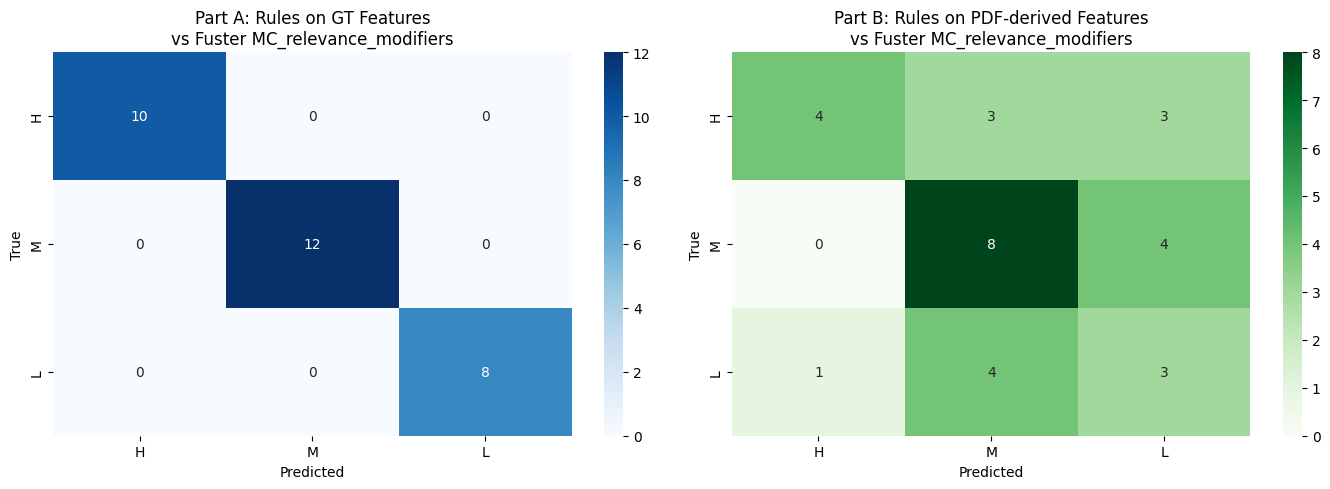

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_a2 = confusion_matrix(eval_df_a["gt_relevance"], eval_df_a["pred_relevance"], labels=labels_a)
sns.heatmap(cm_a2, annot=True, fmt="d", xticklabels=labels_a, yticklabels=labels_a,
            cmap="Blues", ax=axes[0])
axes[0].set_title("Part A: Rules on GT Features\nvs Fuster MC_relevance_modifiers")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

cm_b = confusion_matrix(y_true_b, y_pred_b, labels=labels_b)
sns.heatmap(cm_b, annot=True, fmt="d", xticklabels=labels_b, yticklabels=labels_b,
            cmap="Greens", ax=axes[1])
axes[1].set_title("Part B: Rules on PDF-derived Features\nvs Fuster MC_relevance_modifiers")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("notebooks/results/relevance_mechanistic_pdf_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary Comparison Table


In [18]:
# Build comparison table
rows = [
    {
        "Method": "R0: Rules on GT features vs Fuster MC+Modulators",
        "4-class macro F1": round(macro_f1_a, 3),
        "Binary F1 (relevant)": round(f1_a, 3),
        "Binary P": round(p_a, 3),
        "Binary R": round(r_a, 3),
    },
    {
        "Method": "R1-B: Rules on PDF-derived LLM features vs Fuster MC+Modulators",
        "4-class macro F1": round(macro_f1_b, 3),
        "Binary F1 (relevant)": round(f1_b, 3),
        "Binary P": round(p_b, 3),
        "Binary R": round(r_b, 3),
    },
]

if p_ref is not None:
    rows.append({
        "Method": "Diagnostic: Fuster MC+Modulators vs human dataset_relevance",
        "4-class macro F1": round(macro_f1_ref, 3),
        "Binary F1 (relevant)": round(f1_ref, 3),
        "Binary P": round(p_ref, 3),
        "Binary R": round(r_ref, 3),
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv("notebooks/results/relevance_mechanistic_pdf_summary.csv", index=False)
print("Saved summary to notebooks/results/relevance_mechanistic_pdf_summary.csv\n")
summary_df


Saved summary to notebooks/results/relevance_mechanistic_pdf_summary.csv



,Method,4-class macro F1,Binary F1 (relevant),Binary P,Binary R
0,R0: Rules on GT features vs Fuster MC+Modula...,1.000,1.000,1.000,1.000
1,R1-B: Rules on PDF-derived LLM features vs Fus...,0.486,0.714,0.750,0.682
2,Diagnostic: Fuster MC+Modulators vs human data...,0.491,0.850,0.773,0.944


## Delta Analysis — Part A vs Part B

How much does imperfect feature extraction degrade relevance scoring?

In [19]:
# Compare Part A and Part B predictions side-by-side
# Align on shared gt_record_id
shared_ids = set(eval_df_a["id"]) & set(pred_eval_df["id"])
part_a_sub = eval_df_a[eval_df_a["id"].isin(shared_ids)][
    ["id", "data_type", "temp_range_i", "temp_range_f", "spatial_range_km2", "pred_relevance", "gt_relevance"]
].rename(columns={
    "data_type": "gt_data_type", "temp_range_i": "gt_temp_i", "temp_range_f": "gt_temp_f",
    "spatial_range_km2": "gt_spatial", "pred_relevance": "pred_a"
})

part_b_sub = pred_eval_df[pred_eval_df["id"].isin(shared_ids)][
    ["id", "data_type", "temp_range_i", "temp_range_f", "spatial_range_km2", "pred_relevance"]
].rename(columns={
    "data_type": "llm_data_type", "temp_range_i": "llm_temp_i", "temp_range_f": "llm_temp_f",
    "spatial_range_km2": "llm_spatial", "pred_relevance": "pred_b"
})

delta_df = part_a_sub.merge(part_b_sub, on="id")
delta_df["match"] = delta_df["pred_a"] == delta_df["pred_b"]
delta_df["both_correct_a"] = delta_df["pred_a"] == delta_df["gt_relevance"]
delta_df["both_correct_b"] = delta_df["pred_b"] == delta_df["gt_relevance"]

print(f"Records with both Part A and Part B predictions: {len(delta_df)}")
print(f"Part A == Part B: {delta_df['match'].sum()}/{len(delta_df)} ({delta_df['match'].mean():.1%})")
print(f"Correct in A: {delta_df['both_correct_a'].sum()}")
print(f"Correct in B: {delta_df['both_correct_b'].sum()}")
print(f"\nDegraded by LLM features (A correct, B wrong): {(delta_df['both_correct_a'] & ~delta_df['both_correct_b']).sum()}")
print(f"Improved by LLM features (A wrong, B correct): {(~delta_df['both_correct_a'] & delta_df['both_correct_b']).sum()}")

delta_df[["id", "gt_relevance", "gt_data_type", "llm_data_type", "pred_a", "pred_b", "match"]].head(10)

Records with both Part A and Part B predictions: 30
Part A == Part B: 15/30 (50.0%)
Correct in A: 30
Correct in B: 15

Degraded by LLM features (A correct, B wrong): 15
Improved by LLM features (A wrong, B correct): 0


,id,gt_relevance,gt_data_type,llm_data_type,pred_a,pred_b,match
0,5,M,[genetic_analysis],[genetic_analysis],M,M,True
1,9,L,[density],[abundance],L,M,False
2,11,M,[presence-only],"[time_series, presence-only]",M,L,False
3,12,H,[other],"[presence-only, time_series]",H,H,True
4,19,M,"[presence-only, genetic_analysis]",[genetic_analysis],M,L,False
5,24,H,[genetic_analysis],[genetic_analysis],H,L,False
6,27,M,"[presence-only, genetic_analysis]","[genetic_analysis, presence-only]",M,M,True
7,29,H,[abundance],[abundance],H,H,True
8,30,H,[presence-only],[time_series],H,L,False
9,31,L,[genetic_analysis],"[abundance, genetic_analysis, traits]",L,L,True
